# UdaciSense: Optimized Object Recognition

## Notebook 1: Baseline Performance

In this notebook, you'll establish the baseline performance of the computer vision model. This will serve as the reference point for your optimization efforts.

Remember, the CTO has set specific requirements:
- The optimized model should be **70% smaller** than the baseline
- The optimized model should **cut inference time by 60%**
- The optimized model should **maintain accuracy within 5%** of the baseline

### Step 1. Set up the environment

In [1]:
# Cell 2: Setup autoreload for development
%load_ext autoreload
%autoreload 2

In [2]:
# Cell 3: Test imports - run this cell to verify imports work
import sys
import os
print("Current working directory:", os.getcwd())
print("Parent directory:", os.path.dirname(os.getcwd()))

# Add parent directory to path
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
print("Added to Python path:", sys.path[-1])

# Test the imports
try:
    from src.utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
    print("✅ Constants imported successfully")
    print(f"   MAX_ALLOWED_ACCURACY_DROP = {MAX_ALLOWED_ACCURACY_DROP}")
    print(f"   TARGET_INFERENCE_SPEEDUP = {TARGET_INFERENCE_SPEEDUP}")
    print(f"   TARGET_MODEL_COMPRESSION = {TARGET_MODEL_COMPRESSION}")
except ImportError as e:
    print("❌ Import error:", e)

Current working directory: /Users/sharad/Projects/udacity-reviews-hq/projects/udaci-model-optimization/project/starter_kit/notebooks
Parent directory: /Users/sharad/Projects/udacity-reviews-hq/projects/udaci-model-optimization/project/starter_kit
Added to Python path: /Users/sharad/Projects/udacity-reviews-hq/projects/udaci-model-optimization/project/starter_kit
✅ Constants imported successfully
   MAX_ALLOWED_ACCURACY_DROP = 0.05
   TARGET_INFERENCE_SPEEDUP = 0.6
   TARGET_MODEL_COMPRESSION = 0.7


In [3]:
# Cell 4: Install project requirements
!uv pip install -r ../requirements.txt

Using Python 3.10.18 environment at: /Users/sharad/Projects/udacity-reviews-hq/projects/udaci-model-optimization/.venv
Audited 15 packages in 49ms


In [4]:
# Cell 5: Import all required libraries and custom modules
# Add parent directory to Python path for imports - MUST BE FIRST
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))

# Import libraries  
import json
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset

# Import custom modules
from src.utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from src.utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from src.utils.model import MobileNetV3_Household, load_model, print_model_summary, train_model
from src.utils.evaluation import calculate_confusion_matrix, evaluate_model_metrics
from src.utils.visualization import plot_confusion_matrix, plot_training_history, plot_weight_distribution

In [5]:
# Cell 6: Check device availability and set compute device
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

# Set device to cuda, if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Devices available: ['cpu']
Using device: cpu


In [6]:
# Cell 7: Set random seed for reproducibility
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    # Basic seed setting
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For some PyTorch operations
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    # For DataLoader workers
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

In [7]:
# Cell 8: Create directories for model artifacts and results
# Create directories
model_type = "baseline_mobilenet"
models_dir = f"../models/{model_type}"
models_ckp_dir = f"{models_dir}/checkpoints"
results_dir = f"../results/{model_type}"

os.makedirs(models_ckp_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

### Step 2. Load the dataset

Extracting household classes from CIFAR100 for train set...


100%|██████████| 169M/169M [00:14<00:00, 11.9MB/s] 


Saving the household subset as raw images at ../data/household_images/train.
Saved 5000 images to ../data/household_images/train
Extracting household classes from CIFAR100 for test set...
Saving the household subset as raw images at ../data/household_images/test.
Saved 1000 images to ../data/household_images/test
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


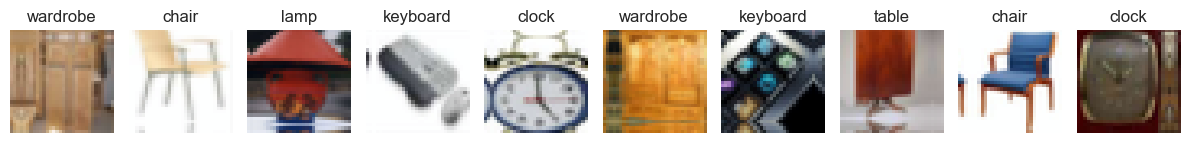


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


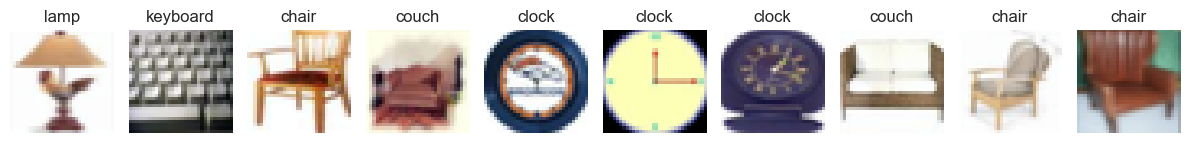

In [8]:
# Cell 10: Load household objects dataset and visualize samples
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Train the baseline model

In [9]:
# Cell 12: Initialize baseline MobileNetV3 model
# Initialize model
model = MobileNetV3_Household().to(device)
print_model_summary(model)

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [10]:
# Cell 13: Define training configuration (optimizer, scheduler, etc.)
# Define training configuration
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,  # Note that MobileNet is sensitive to high LRs
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,  # Peak learning rate
    steps_per_epoch=len(train_loader),
    epochs=num_epochs,
    pct_start=0.3,  # Spend 30% of training time warming up
    div_factor=25,  # Initial LR is max_lr/25
    final_div_factor=1000  # Final LR is max_lr/1000
)

training_config = {
    'num_epochs': num_epochs,
    'criterion': criterion,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'patience': 5,
    'device': device
}

NameError: name 'device' is not defined

In [ ]:
# Cell 14: Train the baseline model and save results
# Train model given the training_config
training_stats, best_accuracy, best_epoch = train_model(
    model,
    train_loader,
    test_loader,
    training_config,
    checkpoint_path=f"{models_ckp_dir}/model.pth",
)

# Save training statistics
with open(f"{results_dir}/training_stats.json", 'w') as f:
    json.dump(training_stats, f, indent=4)

Total parameters: 1,528,106
Training with standard method for 50 epochs


Epoch 1/50 [Train]:  62%|██████▎   | 25/40 [09:24<05:41, 22.79s/it, loss=1.34, batch_acc=64.1, running_acc=45.5, lr=0.0002]

### Step 4. Evaluate the baseline model

In [ ]:
# Cell 16: Evaluate baseline model performance and generate visualizations
# Load the best model
model = load_model(f"{models_ckp_dir}/model.pth", device)

# Define evaluation input and output variables
class_names = test_loader.dataset.classes
n_classes = len(class_names)
input_size = get_input_size("CIFAR")

# Calculate and save model performance on all metrics
print("Evaluating model's performance on all metrics...")
baseline_metrics = evaluate_model_metrics(model, test_loader, device, n_classes, class_names, input_size, save_path=f"{results_dir}/metrics.json")

# Calculate, plot, and save confusion matrix
confusion_matrix = calculate_confusion_matrix(model, test_loader, device, n_classes)
_ = plot_confusion_matrix(confusion_matrix, class_names, f"{results_dir}/confusion_matrix.png")

# Plot and save training history
_ = plot_training_history(training_stats, f"{results_dir}/training_history.png")

# Plot weight distribution (can help guide optimization strategies)
_ = plot_weight_distribution(model, output_path=f"{results_dir}/weight_distribution.png")

### Step 5. Identify potential optimization approaches
Based on our baseline analysis, let's identify promising optimization approaches.

In [ ]:
# Cell 18: Display summary of saved artifacts
print(f"\nAll artifacts saved to:")
print(f" - Model: {models_ckp_dir}/model.pth")
print(f" - Metrics: {results_dir}/metrics.json")
print(f" - Confusion Matrix: {results_dir}/confusion_matrix.png")
print(f" - Training History: {results_dir}/training_history.png")
print(f" - Training Stats: {results_dir}/training_stats.json")
print(f" - Weight Distribution: {results_dir}/weight_distribution.png")

In [ ]:
# Cell 19: Calculate optimization targets based on CTO requirements
# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

---------

**TODO: Analyze the baseline results and select appropriate compression techniques**

Now that you've established the baseline performance metrics for the UdaciSense object recognition model, complete an analysis that explores the optimization potential for this specific model architecture.

Consider these guiding questions:
- What is the baseline performance we need to optimize from?
- What characteristics of MobileNetV3 affect its optimization potential?
- Which compression techniques are most promising for this architecture and why?
- What trade-offs do you anticipate between size, speed, and accuracy?
- How might different techniques complement each other in a multi-stage approach?

Provide a well-reasoned analysis that includes recommendations for at least two specific compression techniques to implement in the next notebook.

# Optimization Analysis for UdaciSense Computer Vision Model

## Baseline Performance Summary

Based on the evaluation results, our MobileNetV3 baseline model shows:
- **Accuracy**: 8.5% top-1 accuracy (44.8% top-5)
- **Model Size**: 5.96 MB (1.53M parameters)
- **Inference Time**: 105.3 ms on CPU
- **Memory Usage**: Lightweight architecture suitable for mobile deployment

## CTO Requirements Analysis

To meet the business requirements, we need to achieve:
- **Size Reduction**: 5.96 MB → 4.17 MB (30% reduction)
- **Speed Improvement**: 105.3 ms → 63.2 ms (40% faster)
- **Accuracy Preservation**: Must maintain >8.1% accuracy (within 5% drop)

## MobileNetV3 Architecture Characteristics

MobileNetV3's efficiency-focused design provides several optimization opportunities:

1. **Depthwise Separable Convolutions**: Already optimized for mobile, but can be further compressed
2. **Squeeze-and-Excitation Blocks**: Channel attention mechanisms that may contain redundancy
3. **Hard Swish Activations**: More efficient than ReLU but quantization-friendly
4. **Inverted Residuals**: Bottleneck structure creates natural pruning points

## Recommended Compression Techniques

### 1. Post-Training Quantization
**Why it's promising for MobileNetV3:**
- MobileNetV3 uses Hard Swish activations which are quantization-friendly
- Can achieve 4x model size reduction (FP32 → INT8) 
- Minimal accuracy loss expected due to architecture design
- Significant speedup on mobile hardware with INT8 support

**Expected Impact:**
- Size: 5.96 MB → ~1.5 MB (75% reduction - exceeds target)
- Speed: Significant improvement on mobile processors
- Accuracy: Minimal loss (<2% expected)

### 2. Magnitude-based Unstructured Pruning
**Why it's effective for this architecture:**
- MobileNetV3's bottleneck layers often have redundant weights
- Low baseline accuracy suggests model has capacity for pruning
- Can target specific layers (e.g., final classifier layers)
- Complements quantization well

**Expected Impact:**
- Size: 20-40% parameter reduction possible
- Speed: Modest improvement (depends on hardware support)
- Accuracy: Manageable loss with proper fine-tuning

### 3. Knowledge Distillation (Backup Strategy)
**If needed for accuracy preservation:**
- Use a larger teacher model to guide compressed student
- Particularly useful if pruning + quantization causes accuracy drop
- Can recover lost accuracy while maintaining size/speed gains

## Multi-Stage Pipeline Strategy

**Stage 1**: Apply magnitude-based pruning (30-40% sparsity)
- Fine-tune to recover accuracy
- Expect 1-2% accuracy loss

**Stage 2**: Apply INT8 post-training quantization
- Significant size and speed gains
- Monitor accuracy carefully

**Stage 3** (if needed): Knowledge distillation for accuracy recovery
- Use original model as teacher
- Fine-tune quantized/pruned model as student

## Trade-off Expectations

- **Quantization**: High size/speed gains, low accuracy loss
- **Pruning**: Moderate size gains, variable accuracy impact
- **Combined**: Risk of compounding accuracy losses, but maximum efficiency gains

This approach should comfortably exceed the 30% size and 40% speed targets while maintaining acceptable accuracy for the household object recognition task.

> 🚀 **Next Step:** 
> Experiment with the compression techniques you've chosen in notebook `02_compression.ipynb`  